# Assignment 3
### Due 9/21. Do four of five.

In [14]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
import plotly.express as px



1. 
- Open the NHANES (or Ames prices or college completion datasets, if you prefer)
- Find two categorical variables of interest (there are 198, and short descriptions are given in the `nhanes_meta_17_18.csv` file). Investigate their missing values (you don't have to focus on missing values for this analysis like we did with police use of force, but always be aware of how dirty the data are)
- Compute a contingency table for your categorical $X$ and $Y$
- Discuss any interesting patterns (or lack of one) that you observe

In [3]:
collegedf = pd.read_csv('/Users/michaeldunlap/Desktop/Recents/UVA_MSDS_Work/Understanding_Uncertainty/understanding_uncertainty_michael_dunlap/data/college_completion.csv')

In [5]:
collegedf['name_na'] = collegedf['chronname'].isna() 
collegedf['name_na'].value_counts() 
collegedf['level_na'] = collegedf['level'].isna() 
collegedf['level_na'].value_counts() 

level_na
False    3798
Name: count, dtype: int64

In [ ]:
pd.crosstab(collegedf['name_na'],collegedf['level_na']) 

level_na,False
name_na,
False,3798


My assesment of this is that neither of these columns has an NA values, this makes sense. 

In [8]:
pd.crosstab(collegedf['chronname'], collegedf['level'], normalize='columns')

level,2-year,4-year
chronname,,
AIB College of Business,0.000000,0.000428
ASA Institute of Business & Computer Technology,0.000685,0.000000
ATA College,0.000685,0.000000
ATS Institute of Technology,0.000685,0.000000
Abilene Christian University,0.000000,0.000428
...,...,...
Young Harris College,0.000000,0.000428
Youngstown State University,0.000000,0.000428
Yuba College,0.000685,0.000000


There are a lot of college so I don't think this is the best way to visualize the data. And this is also probably a bad column to use for that reason. I will say I think because the number for each record in the 4-year column is smaller that it probably means there are more 4-year then 2-year colleges in the dataset (each record is a smaller percentage of the overall)

2. 
- Open the NHANES dataset
- Find a categorical and numeric variable of interest (there are 198, and short descriptions are given in the `nhanes_meta_17_18.csv` file). Investigate their missing values (you don't have to focus on missing values for this analysis, but always be aware of them)
- Make descriptive tables and grouped kernel density plots to represent the variation in your numeric $Y$ conditional on your categorical $X$
- Discuss any interesting patterns (or lack of one) that you observe

In [10]:
nhanes_data = pd.read_csv('/Users/michaeldunlap/Desktop/Recents/UVA_MSDS_Work/Understanding_Uncertainty/understanding_uncertainty_michael_dunlap/data/nhanes_data_17_18.csv')

/var/folders/gr/5b74bfbs70x7jql3hkfyndmm0000gn/T/ipykernel_78932/2937671835.py:1: DtypeWarning: Columns (142) have mixed types. Specify dtype option on import or set low_memory=False.
  nhanes_data = pd.read_csv('/Users/michaeldunlap/Desktop/Recents/UVA_MSDS_Work/Understanding_Uncertainty/understanding_uncertainty_michael_dunlap/data/nhanes_data_17_18.csv')


In [11]:
nhanes_data['milk_na'] = nhanes_data['Past30DayMilkProductConsumption'].isna() 
nhanes_data['milk_na'].value_counts() 
nhanes_data['weight_na'] = nhanes_data['CurrentSelfreportedWeightPounds'].isna() 
nhanes_data['weight_na'].value_counts() 

weight_na
False    5828
True     2538
Name: count, dtype: int64

In [12]:
pd.crosstab(nhanes_data['milk_na'],nhanes_data['weight_na']) 

weight_na,False,True
milk_na,,
False,5828,2537
True,0,1


In [14]:
pd.crosstab(nhanes_data['Past30DayMilkProductConsumption'], nhanes_data['CurrentSelfreportedWeightPounds'], normalize='columns')

CurrentSelfreportedWeightPounds,72.0,80.0,82.0,85.0,86.0,88.0,89.0,90.0,91.0,92.0,...,398.0,400.0,405.0,415.0,416.0,450.0,457.0,484.0,7777.0,9999.0
Past30DayMilkProductConsumption,,,,,,,,,,,,,,,,,,,,,
Never,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.142857,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.5,1.0,0.0,0.500,0.229167
Often-once a day or more?,0.0,1.0,0.5,1.0,0.5,1.0,0.5,0.428571,1.0,0.0,...,0.5,0.333333,1.0,0.0,0.0,0.0,0.0,0.0,0.250,0.302083
Rarely-less than once a week,0.0,0.0,0.5,0.0,0.5,0.0,0.5,0.428571,0.0,1.0,...,0.0,0.333333,0.0,0.0,0.0,0.5,0.0,0.0,0.125,0.177083
Sometimes-once a week or more but less than once a day or,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.5,0.333333,0.0,1.0,1.0,0.0,0.0,1.0,0.125,0.291667
Varied,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000000


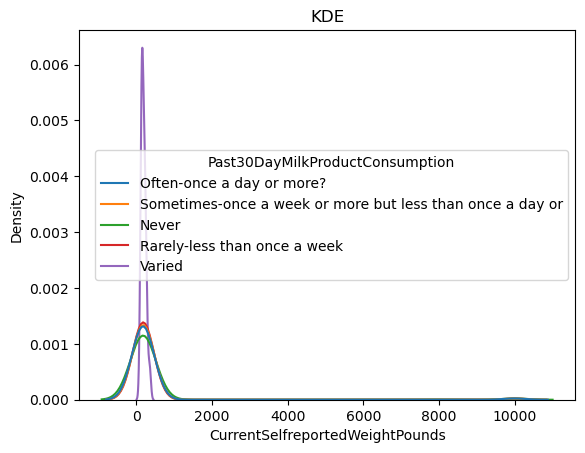

In [24]:
conditioner = 'Past30DayMilkProductConsumption'
sns.kdeplot( data=nhanes_data, x='CurrentSelfreportedWeightPounds', hue=conditioner, common_norm=False ).set(title='KDE')
plt.show()

My biggest takeaway is that they need to handle 9999 better, my assumption is that it is an NA, but it throws off the graph when they are included. The way the graphs are set up, it also makes it look like there are negative weights which doesn't make sense either.

3. 
We showed that the mean and median could be discovered by minimizing various kinds of loss functions; this is what machine learning is. To make a prediction $\hat{y}(z)$ of $Y$ when $X=z$, minimize the mean squared error:
$$
MSE(\hat{y}(z)) = \dfrac{1}{N} \sum_{i=1}^N \left\lbrace y_i - \hat{y}(z) \right\rbrace^2 \frac{1}{h}k\left(\frac{z-x_i}{h}\right)
$$
Show that the solution to this problem is the LCLS/Naradaya-Watson estimator.

The constant that minimizes MSE is the same constant that the LCLS Computes. While they approach it at different directions they have the same end goal, which is to find a value that best fits the data.

4. 
- Write a class or set of functions that implement the LCLS/Naradaya-Watson estimator, using the Silverman plug-in estimate for the conditioning variable $X$ as the bandwidth.
- From one of the course data sets, find two numeric variables of interest, analyze their relationship with the the LCLS/Naradaya-Watson estimator, and discuss your results.

/var/folders/gr/5b74bfbs70x7jql3hkfyndmm0000gn/T/ipykernel_97309/2994333744.py:28: RuntimeWarning:

invalid value encountered in scalar divide



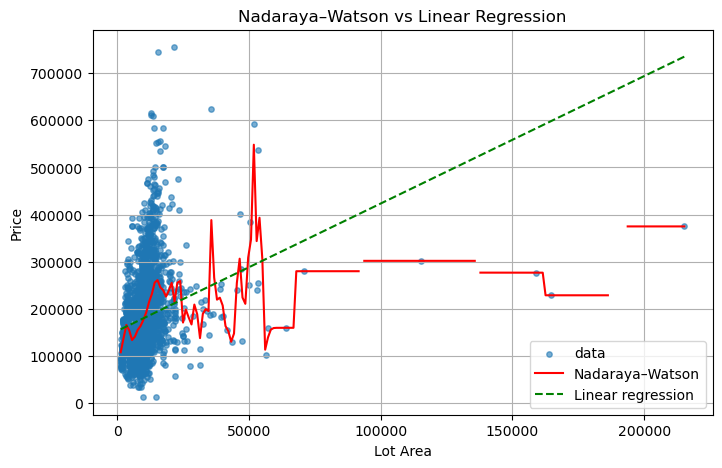

In [ ]:
class NadarayaWatson:
    def __init__(self, bandwidth=None):
        self.bandwidth = bandwidth

    def _silverman_bandwidth(self, x):
        n = len(x)
        sd = np.std(x, ddof=1)
        iqr = np.percentile(x, 75) - np.percentile(x, 25)
        sigma = min(sd, iqr/1.34 if iqr > 0 else sd)
        return 0.9 * sigma * (n ** (-1/5))

    def fit(self, X, y):
        self.X = np.asarray(X).ravel()
        self.y = np.asarray(y).ravel()
        if self.bandwidth is None:
            self.h = self._silverman_bandwidth(self.X)
        else:
            self.h = float(self.bandwidth)
        return self

    def predict(self, z):
        z = np.asarray(z).ravel()
        preds = []
        for zi in z:
            u = (zi - self.X) / self.h
            weights = np.exp(-0.5 * u**2) / np.sqrt(2*np.pi)
            preds.append(np.sum(weights * self.y) / np.sum(weights))
        return np.array(preds)
        
amesdf=pd.read_csv('/Users/michaeldunlap/Desktop/Recents/UVA_MSDS_Work/Understanding_Uncertainty/understanding_uncertainty_michael_dunlap/data/ames_prices.csv')
X = amesdf['Lot.Area']
Y = amesdf['price']
nw = NadarayaWatson()
nw.fit(X, Y)
z_grid = np.linspace(min(X), max(X), 200)
nw_pred = nw.predict(z_grid)
lr = LinearRegression().fit(X.to_numpy().reshape(-1,1), Y)
lr_pred = lr.predict(z_grid.reshape(-1,1))
plt.figure(figsize=(8,5))
plt.scatter(X, Y, s=15, alpha=0.6, label="data")
plt.plot(z_grid, nw_pred, color="red", label="Nadaraya–Watson")
plt.plot(z_grid, lr_pred, color="green", linestyle="--", label="Linear regression")
plt.xlabel("Lot Area")
plt.ylabel("Price")
plt.title("Nadaraya–Watson vs Linear Regression")
plt.legend()
plt.grid(True)
plt.show()


5. 
- In any of the available data sets, investigate the relationships between pairs of variables $(X,Y)$ with a scatterplot and CEF (for example, price on area)
- Is this relationship plausibly causal, or are there missing variables that might explain at least part of the relationship between your variables? These can be "conceptual" rather than "practical"; for example, 'talent' or 'grit' probably explain education outcomes, but are almost impossible to measure. We are asking whether there are hypothetical **threats to causal identification** of the effect of $X$ on $Y$.
- Explain how, regardless of the threat to causal identification, you can still use your model to predict $Y$ given $X$, as long as you don't intervene in the system to control the outcome

In [12]:

df2 = amesdf[["Lot.Area","price"]]
corr=df2.corr()
corr

,Lot.Area,price
Lot.Area,1.000000,0.266549
price,0.266549,1.000000


In [15]:
px.imshow(corr,text_auto=".2f", color_continuous_scale="Picnic")

I think this shows that the connection between price and lot area isn't all that strong. There are likely other variables that effect price, like house area or number of chimneys. I do think we can still use lot area to predict price, while it wouldn't be a perfect fit I believe it makes sense. Overall, the larger a plot is the higher the price, so not a perfect fit, but one that would allow you to at least see the relationship involved.

I will say based on this analysis, that it would likely be better to pick a different predictor for price, a better fit probably exists.